# Segmentation: company performance clusters

C:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


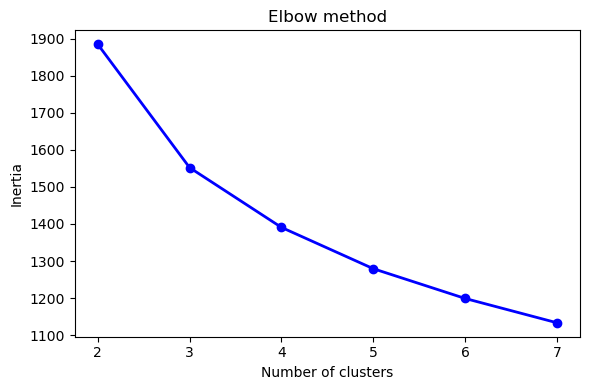

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/industry_benchmark.csv')
features = ['turnover_rate','engagement_score','eNPS','training_hours_per_employee','revenue_per_employee']
X = StandardScaler().fit_transform(df[features])

inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X).inertia_ for k in range(2, 8)]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(2, 8), inertias, 'bo-', linewidth=2)
ax.set_xlabel('Number of clusters')
ax.set_ylabel('Inertia')
ax.set_title('Elbow method')
plt.tight_layout()
plt.show()

In [2]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X)
print('Cluster profiles:')
df.groupby('cluster')[features].mean().round(3).T

Cluster profiles:


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


cluster,0,1,2,3
turnover_rate,0.178,0.137,0.282,0.147
engagement_score,7.201,6.077,6.003,7.636
eNPS,17.068,14.532,8.289,38.641
training_hours_per_employee,47.412,28.087,18.931,30.338
revenue_per_employee,128580.311,179114.841,140218.244,322827.099


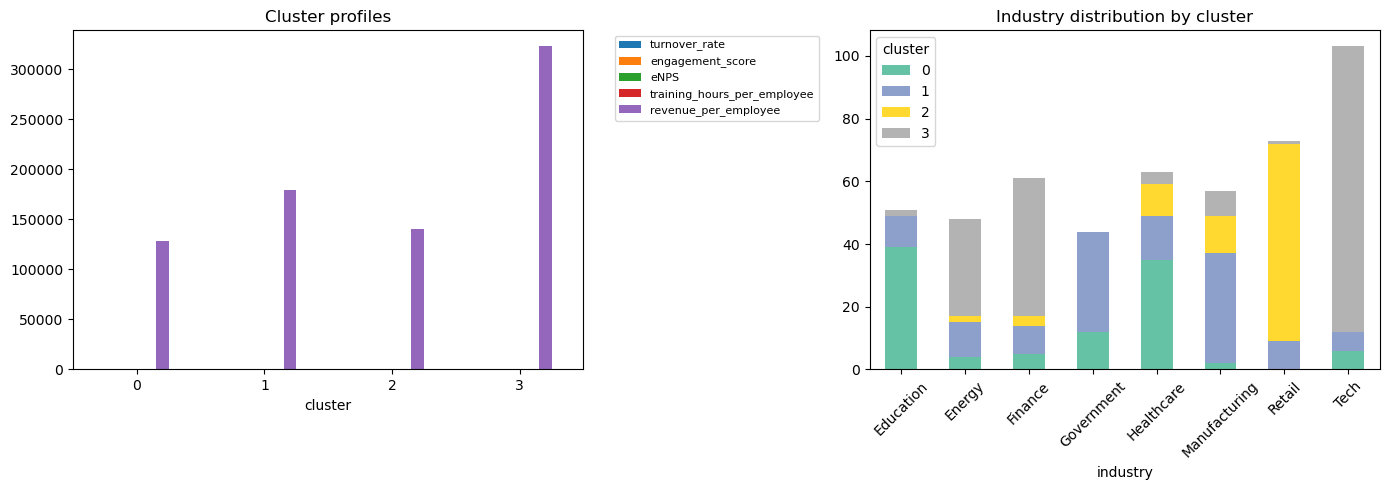

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.groupby('cluster')[features].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('Cluster profiles')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(bbox_to_anchor=(1.05, 1), fontsize=8)

pd.crosstab(df['industry'], df['cluster']).plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Industry distribution by cluster')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()